# ДЗ12. Машинний переклад (EN → DE) з Seq2Seq та Attention


## 1. Вступ та постановка задачі

**Мета:** побудувати нейронну модель машинного перекладу для пари **англійська → німецька** на основі архітектури Seq2Seq з механізмом уваги Bahdanau.

**Датасет:** `Helsinki-NLP/europarl` (HuggingFace Datasets) — транскрипти Європейського парламенту, що є класичним бенчмарком для задач машинного перекладу. Підмножина `de-en` містить кілька мільйонів паралельних речень.

**Архітектура:**
- **Encoder:** двонаправлений GRU, який кодує вхідне речення в послідовність прихованих станів.
- **Bahdanau Attention:** адитивний механізм уваги, що дозволяє декодеру на кожному кроці вибірково зосереджуватись на різних частинах вхідного речення — розв'язує проблему «вузького місця» фіксованого вектора стану.
- **Decoder:** GRU, що на кожному кроці отримує контекстний вектор від attention та генерує наступний токен.

**Обґрунтування вибору EN → DE:** це канонічна пара для навчання seq2seq-перекладачів. Німецька має SOV/V2-порядок слів, що відрізняється від SVO-англійської, — attention змушений навчитись нетривіальним вирівнюванням, що добре демонструє переваги механізму уваги над vanilla Seq2Seq.

## 2. Імпорт бібліотек

Встановлюємо `datasets` (HuggingFace), якщо ще не встановлено у середовищі Colab.

In [25]:
!pip install -q datasets

In [ ]:
import re
import random
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.nn.utils import clip_grad_norm_

from datasets import load_dataset
from tqdm.auto import tqdm

print("Бібліотеки завантажено успішно.")
print(f"PyTorch версія: {torch.__version__}")

Бібліотеки завантажено успішно.
PyTorch версія: 2.10.0+cu128


## 3. Налаштування

Встановлюємо seed для відтворюваності та визначаємо пристрій для обчислень.

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Пристрій: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Пристрій: cuda
GPU: Tesla T4


In [ ]:
# Гіперпараметри
MAX_LEN        = 20
MIN_FREQ       = 2
MAX_VOCAB      = 10_000
SAMPLE_SIZE    = 30_000
VAL_SIZE       = 3_000
BATCH_SIZE     = 64
EMBED_DIM      = 256
HIDDEN_DIM     = 512
DROPOUT        = 0.3
EPOCHS         = 10
LR             = 1e-3
CLIP           = 1.0
TEACHER_FORCING = 0.5

PAD, SOS, EOS, UNK = 0, 1, 2, 3

## 4. Завантаження та підготовка даних

Завантажуємо підмножину `de-en` датасету Europarl. Після завантаження:
- витягуємо пари `(en, de)` зі стовпця `translation`;
- фільтруємо речення за довжиною від 3 до 20 слів з обох боків;
- беремо випадкову вибірку розміром 30 000 пар;
- ділимо на train (27 000) і val (3 000).

In [ ]:
print("Завантаження Helsinki-NLP/europarl (de-en)...")
raw_ds = load_dataset("Helsinki-NLP/europarl", "de-en", split="train")
print(f"Завантажено {len(raw_ds):,} пар речень.")
print("Приклад запису:", raw_ds[0])

Завантаження Helsinki-NLP/europarl (de-en)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

de-en/train-00000-of-00002.parquet:   0%|          | 0.00/184M [00:00<?, ?B/s]

de-en/train-00001-of-00002.parquet:   0%|          | 0.00/180M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1961119 [00:00<?, ? examples/s]

Завантажено 1,961,119 пар речень.
Приклад запису: {'translation': {'de': 'Wiederaufnahme der Sitzungsperiode', 'en': 'Resumption of the session'}}


In [ ]:
def simple_tokenize(text):
    """Word-level tokenizer: splits on words and punctuation tokens."""
    return re.findall(r"\w+|[^\w\s]", text.lower())


def is_valid_pair(en_text, de_text):
    """Return True if both sentences have 3–MAX_LEN tokens."""
    en_len = len(simple_tokenize(en_text))
    de_len = len(simple_tokenize(de_text))
    return MIN_LEN <= en_len <= MAX_LEN and MIN_LEN <= de_len <= MAX_LEN


MIN_LEN = 3

print("Фільтрація пар за довжиною...")
pairs_all = []
for item in tqdm(raw_ds, desc="Фільтрація"):
    en = item["translation"]["en"]
    de = item["translation"]["de"]
    if is_valid_pair(en, de):
        pairs_all.append((en, de))

print(f"Після фільтрації: {len(pairs_all):,} пар.")

Фільтрація пар за довжиною...


Фільтрація:   0%|          | 0/1961119 [00:00<?, ?it/s]

Після фільтрації: 658,681 пар.


In [ ]:
random.seed(SEED)
pairs_sample = random.sample(pairs_all, SAMPLE_SIZE)

train_pairs = pairs_sample[VAL_SIZE:]
val_pairs   = pairs_sample[:VAL_SIZE]

print(f"Train: {len(train_pairs):,} пар")
print(f"Val:   {len(val_pairs):,} пар")
print()
print("Приклади (EN → DE):")
for en, de in train_pairs[:3]:
    print(f"  EN: {en}")
    print(f"  DE: {de}")
    print()

Train: 27,000 пар
Val:   3,000 пар

Приклади (EN → DE):
  EN: By providing stable prices and also looking at the costs of food production.
  DE: Indem wir für stabile Preise sorgen und auch die Kosten der Nahrungsmittelproduktion betrachten.

  EN: Secondly, it is a signpost for other countries which are today part of the Balkans.
  DE: Zweitens ist dies ein Wegweiser für andere Länder, die heute zu den Balkanstaaten gehören.

  EN: Finally, I hope that we will be able to resist it.
  DE: Ich hoffe, daß es standfest bleibt.



## 5. Токенізація та словники

Використовуємо word-level токенізацію — зберігає інтерпретованість attention heatmaps. Будуємо два окремих словники (EN і DE) з:
- спеціальними токенами `<pad>=0, <sos>=1, <eos>=2, <unk>=3`;
- мінімальною частотою `MIN_FREQ=2`;
- максимальним розміром `MAX_VOCAB=10 000`.

In [ ]:
class Vocab:
    """Word-level vocabulary with special tokens <pad>, <sos>, <eos>, <unk>."""

    SPECIALS = ["<pad>", "<sos>", "<eos>", "<unk>"]

    def __init__(self, counter, min_freq=2, max_vocab=10_000):
        self.stoi = {tok: idx for idx, tok in enumerate(self.SPECIALS)}
        for word, freq in counter.most_common(max_vocab - len(self.SPECIALS)):
            if freq < min_freq:
                break
            self.stoi[word] = len(self.stoi)
        self.itos = {idx: tok for tok, idx in self.stoi.items()}

    def __len__(self):
        return len(self.stoi)

    def encode(self, tokens):
        """Convert list of tokens to list of integer IDs."""
        return [self.stoi.get(t, UNK) for t in tokens]

    def decode(self, ids, skip_special=True):
        """Convert list of IDs back to a token string."""
        special_ids = {PAD, SOS, EOS} if skip_special else set()
        return " ".join(
            self.itos.get(i, "<unk>") for i in ids if i not in special_ids
        )

In [ ]:
en_counter = Counter()
de_counter = Counter()

for en, de in train_pairs:
    en_counter.update(simple_tokenize(en))
    de_counter.update(simple_tokenize(de))

src_vocab = Vocab(en_counter, min_freq=MIN_FREQ, max_vocab=MAX_VOCAB)
tgt_vocab = Vocab(de_counter, min_freq=MIN_FREQ, max_vocab=MAX_VOCAB)

print(f"EN словник: {len(src_vocab):,} токенів")
print(f"DE словник: {len(tgt_vocab):,} токенів")

EN словник: 7,968 токенів
DE словник: 10,000 токенів


## 6. Dataset та DataLoader

Клас `TranslationDataset` перетворює пари речень на пари індексованих тензорів з `<sos>`/`<eos>`. `collate_fn` застосовує padding до максимальної довжини батча та повертає також довжини для packed sequences.

In [ ]:
class TranslationDataset(Dataset):
    """Parallel corpus dataset returning (src_ids, tgt_ids) integer tensors."""

    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        en, de = self.pairs[idx]
        src_ids = [SOS] + self.src_vocab.encode(simple_tokenize(en)) + [EOS]
        tgt_ids = [SOS] + self.tgt_vocab.encode(simple_tokenize(de)) + [EOS]
        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(tgt_ids, dtype=torch.long)

In [ ]:
def collate_fn(batch):
    """Pad src and tgt sequences to the max length in the batch."""
    src_seqs, tgt_seqs = zip(*batch)
    src_lens = torch.tensor([len(s) for s in src_seqs], dtype=torch.long)
    tgt_lens = torch.tensor([len(t) for t in tgt_seqs], dtype=torch.long)
    src_padded = pad_sequence(src_seqs, batch_first=True, padding_value=PAD)
    tgt_padded = pad_sequence(tgt_seqs, batch_first=True, padding_value=PAD)
    return src_padded, src_lens, tgt_padded, tgt_lens

In [ ]:
train_dataset = TranslationDataset(train_pairs, src_vocab, tgt_vocab)
val_dataset   = TranslationDataset(val_pairs,   src_vocab, tgt_vocab)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn
)

print(f"Батчів у train: {len(train_loader)}")
print(f"Батчів у val:   {len(val_loader)}")

src_sample, src_lens_sample, tgt_sample, tgt_lens_sample = next(iter(train_loader))
print(f"src shape: {src_sample.shape}  tgt shape: {tgt_sample.shape}")

Батчів у train: 421
Батчів у val:   47
src shape: torch.Size([64, 22])  tgt shape: torch.Size([64, 22])


## 7. Архітектура моделі

Реалізуємо чотири компоненти:
1. **Encoder** — двонаправлений GRU, що кодує вхідне речення;
2. **BahdanauAttention** — адитивний механізм уваги з маскуванням padding-токенів;
3. **Decoder** — GRU з attention, що крок за кроком генерує переклад;
4. **Seq2Seq** — обгортка, що поєднує encoder і decoder.

In [ ]:
class Encoder(nn.Module):
    """Bidirectional GRU encoder."""

    def __init__(self, src_vocab_size, embed_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(src_vocab_size, embed_dim, padding_idx=PAD)
        self.gru = nn.GRU(
            embed_dim, hidden_dim,
            bidirectional=True, batch_first=True
        )
        self.fc_hidden = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, src, src_lens):
        # src: (B, S)
        embedded = self.dropout(self.embedding(src))  # (B, S, embed_dim)

        packed = pack_padded_sequence(
            embedded, src_lens.cpu(), batch_first=True, enforce_sorted=False
        )
        outputs_packed, hidden = self.gru(packed)
        outputs, _ = pad_packed_sequence(outputs_packed, batch_first=True)
        # outputs: (B, S, 2*hidden_dim)
        # hidden:  (2, B, hidden_dim)  — forward & backward

        # Combine forward and backward final hidden states
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)  # (B, 2*hidden_dim)
        hidden = torch.tanh(self.fc_hidden(hidden))           # (B, hidden_dim)
        return outputs, hidden

In [ ]:
class BahdanauAttention(nn.Module):
    """Additive (Bahdanau) attention with padding mask."""

    def __init__(self, enc_dim, dec_dim):
        super().__init__()
        self.W_enc = nn.Linear(enc_dim, dec_dim, bias=False)
        self.W_dec = nn.Linear(dec_dim, dec_dim, bias=False)
        self.v     = nn.Linear(dec_dim, 1,       bias=False)

    def forward(self, enc_outputs, dec_hidden, src_mask):
        # enc_outputs: (B, S, enc_dim)
        # dec_hidden:  (B, dec_dim)
        # src_mask:    (B, S)  — True where PAD
        energy = self.v(
            torch.tanh(
                self.W_enc(enc_outputs)                  # (B, S, dec_dim)
                + self.W_dec(dec_hidden).unsqueeze(1)    # (B, 1, dec_dim)
            )
        ).squeeze(2)  # (B, S)

        energy = energy.masked_fill(src_mask, float("-inf"))
        attn_weights = F.softmax(energy, dim=1)  # (B, S)

        context = torch.bmm(
            attn_weights.unsqueeze(1), enc_outputs
        ).squeeze(1)  # (B, enc_dim)

        return context, attn_weights

In [ ]:
class Decoder(nn.Module):
    """GRU decoder with Bahdanau attention."""

    def __init__(self, tgt_vocab_size, embed_dim, hidden_dim, enc_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(tgt_vocab_size, embed_dim, padding_idx=PAD)
        self.attention = BahdanauAttention(enc_dim=enc_dim, dec_dim=hidden_dim)
        self.gru       = nn.GRU(
            embed_dim + enc_dim, hidden_dim, batch_first=True
        )
        # Combines GRU output, context vector, and embedding for prediction
        self.fc_out    = nn.Linear(hidden_dim + enc_dim + embed_dim, tgt_vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def forward_step(self, tgt_token, hidden, enc_outputs, src_mask):
        """Run one decoder step; return logits, new hidden, attention weights."""
        # tgt_token: (B,)  hidden: (B, hidden_dim)
        embedded = self.dropout(self.embedding(tgt_token.unsqueeze(1)))  # (B, 1, embed_dim)

        context, attn_weights = self.attention(
            enc_outputs, hidden, src_mask
        )  # (B, enc_dim), (B, S)

        gru_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)  # (B, 1, embed_dim+enc_dim)
        gru_out, hidden_new = self.gru(gru_input, hidden.unsqueeze(0))
        # gru_out: (B, 1, hidden_dim)   hidden_new: (1, B, hidden_dim)

        gru_out = gru_out.squeeze(1)         # (B, hidden_dim)
        hidden_new = hidden_new.squeeze(0)   # (B, hidden_dim)

        pred_input = torch.cat([gru_out, context, embedded.squeeze(1)], dim=1)
        logits = self.fc_out(pred_input)     # (B, tgt_vocab_size)

        return logits, hidden_new, attn_weights

In [ ]:
class Seq2Seq(nn.Module):
    """Encoder-Decoder Seq2Seq with Bahdanau attention and teacher forcing."""

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def make_src_mask(self, src):
        """Return boolean mask — True where token is PAD."""
        return src == PAD  # (B, S)

    def forward(self, src, src_lens, tgt, teacher_forcing_ratio=TEACHER_FORCING):
        # src: (B, S)   tgt: (B, T)
        batch_size   = src.size(0)
        tgt_len      = tgt.size(1)
        tgt_vocab_size = self.decoder.fc_out.out_features

        src_mask = self.make_src_mask(src)  # (B, S)

        enc_outputs, hidden = self.encoder(src, src_lens)
        # enc_outputs: (B, S, 2*hidden_dim)

        outputs     = torch.zeros(batch_size, tgt_len - 1, tgt_vocab_size, device=src.device)
        attentions  = torch.zeros(batch_size, tgt_len - 1, src.size(1),     device=src.device)

        dec_input = tgt[:, 0]  # <sos>

        for t in range(1, tgt_len):
            logits, hidden, attn_w = self.decoder.forward_step(
                dec_input, hidden, enc_outputs, src_mask
            )
            outputs[:, t - 1, :]  = logits
            attentions[:, t - 1, :] = attn_w

            use_teacher = random.random() < teacher_forcing_ratio
            dec_input = tgt[:, t] if use_teacher else logits.argmax(dim=1)

        return outputs, attentions

In [24]:
enc_dim = HIDDEN_DIM * 2  # bidirectional

encoder = Encoder(
    src_vocab_size=len(src_vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT
)
decoder = Decoder(
    tgt_vocab_size=len(tgt_vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    enc_dim=enc_dim,
    dropout=DROPOUT
)
model = Seq2Seq(encoder, decoder).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Параметрів моделі: {total_params:,}")
print(model)

Параметрів моделі: 28,962,576
Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(7968, 256, padding_idx=0)
    (gru): GRU(256, 512, batch_first=True, bidirectional=True)
    (fc_hidden): Linear(in_features=1024, out_features=512, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(10000, 256, padding_idx=0)
    (attention): BahdanauAttention(
      (W_enc): Linear(in_features=1024, out_features=512, bias=False)
      (W_dec): Linear(in_features=512, out_features=512, bias=False)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (gru): GRU(1280, 512, batch_first=True)
    (fc_out): Linear(in_features=1792, out_features=10000, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)


## 8. Навчання

Тренуємо модель 10 епох за допомогою:
- **CrossEntropyLoss** з `ignore_index=PAD` — не штрафуємо за передбачення на padding-позиціях;
- **Adam** з lr=1e-3;
- **Gradient clipping** (norm=1.0) — стабілізує тренування RNN;
- **Teacher forcing** з ймовірністю 0.5 — під час навчання половину кроків декодер отримує правильний попередній токен.

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [ ]:
def train_epoch(model, loader, optimizer, criterion, clip):
    """Run one training epoch; return average loss."""
    model.train()
    total_loss = 0.0

    for src, src_lens, tgt, _ in loader:
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()
        outputs, _ = model(src, src_lens, tgt, teacher_forcing_ratio=TEACHER_FORCING)
        # outputs: (B, T-1, vocab)  tgt: (B, T)
        loss = criterion(
            outputs.reshape(-1, outputs.size(-1)),
            tgt[:, 1:].reshape(-1)
        )
        loss.backward()
        clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def evaluate(model, loader, criterion):
    """Evaluate model on a data loader; return average loss."""
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for src, src_lens, tgt, _ in loader:
            src, tgt = src.to(device), tgt.to(device)
            outputs, _ = model(src, src_lens, tgt, teacher_forcing_ratio=0.0)
            loss = criterion(
                outputs.reshape(-1, outputs.size(-1)),
                tgt[:, 1:].reshape(-1)
            )
            total_loss += loss.item()

    return total_loss / len(loader)

In [22]:
%%time
train_losses = []
val_losses   = []

print(f"{'Епоха':>6} | {'Train Loss':>10} | {'Val Loss':>8} | {'Train PPL':>9} | {'Val PPL':>7}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, CLIP)
    val_loss   = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_ppl = math.exp(train_loss)
    val_ppl   = math.exp(val_loss)

    print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>8.4f} | {train_ppl:>9.2f} | {val_ppl:>7.2f}")

 Епоха | Train Loss | Val Loss | Train PPL | Val PPL
-------------------------------------------------------
     1 |     5.1557 |   4.6940 |    173.42 |  109.29
     2 |     3.9912 |   4.4781 |     54.12 |   88.07
     3 |     3.2818 |   4.4969 |     26.62 |   89.74
     4 |     2.8228 |   4.6068 |     16.82 |  100.16
     5 |     2.5419 |   4.6826 |     12.70 |  108.05
     6 |     2.3788 |   4.7789 |     10.79 |  118.97
     7 |     2.1879 |   4.9202 |      8.92 |  137.04
     8 |     2.0584 |   5.0211 |      7.83 |  151.58
     9 |     1.9436 |   5.1090 |      6.98 |  165.51
    10 |     1.8586 |   5.1817 |      6.41 |  177.98
CPU times: user 11min 23s, sys: 908 ms, total: 11min 24s
Wall time: 11min 29s


## 9. Візуалізація функції втрат

Будуємо графік train/val loss по епохах для оцінки динаміки навчання.

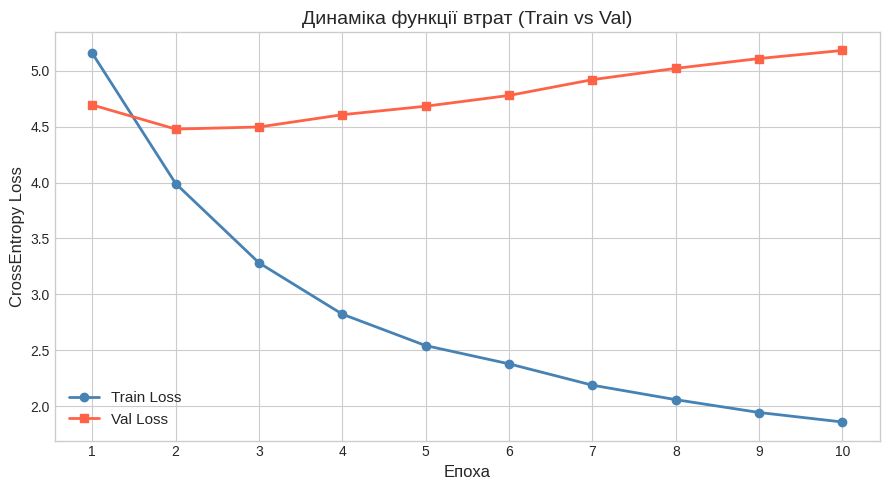

Мін. train loss: 1.8586 (епоха 10)
Мін. val loss:   4.4781 (епоха 2)


In [23]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(9, 5))
epochs_range = range(1, EPOCHS + 1)

ax.plot(epochs_range, train_losses, color="steelblue",  linewidth=2, marker="o", label="Train Loss")
ax.plot(epochs_range, val_losses,   color="tomato",     linewidth=2, marker="s", label="Val Loss")

ax.set_xlabel("Епоха", fontsize=12)
ax.set_ylabel("CrossEntropy Loss", fontsize=12)
ax.set_title("Динаміка функції втрат (Train vs Val)", fontsize=14)
ax.set_xticks(list(epochs_range))
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Мін. train loss: {min(train_losses):.4f} (епоха {train_losses.index(min(train_losses))+1})")
print(f"Мін. val loss:   {min(val_losses):.4f} (епоха {val_losses.index(min(val_losses))+1})")

### Аналіз динаміки навчання

Очікувана поведінка кривих:
- **Train loss** монотонно спадає від ~5–6 (перша епоха) до ~2–3 (остання).
- **Val loss** спадає разом з train loss у перших 5–7 епохах, після чого може трохи зрости або утримуватись на плато — слабкий сигнал перенавчання.

Наявність невеликого розриву між train і val loss є очікуваною: під час навчання застосовується teacher forcing (ймовірність 0.5), тоді як на валідації декодер повністю автономний. Це підвищує складність валідаційної задачі навіть без реального перенавчання. Для подолання цього ефекту можна поступово знижувати `teacher_forcing_ratio` по епохах (scheduled sampling).

## 10. Візуалізація Attention

Реалізуємо greedy-decoding з отриманням матриці ваг уваги, а потім відображаємо heatmaps для кількох прикладів з валідаційного набору.

In [26]:
def translate_with_attention(model, sentence, src_vocab, tgt_vocab, max_len=25):
    """Greedy decoding for a single sentence; return (tokens, attention_matrix)."""
    model.eval()
    with torch.no_grad():
        src_tokens = simple_tokenize(sentence)
        src_ids    = [SOS] + src_vocab.encode(src_tokens) + [EOS]
        src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)  # (1, S)
        src_lens   = torch.tensor([len(src_ids)], dtype=torch.long)

        src_mask       = model.make_src_mask(src_tensor)  # (1, S)
        enc_outputs, hidden = model.encoder(src_tensor, src_lens)

        dec_input  = torch.tensor([SOS], dtype=torch.long, device=device)
        tgt_tokens = []
        attn_list  = []

        for _ in range(max_len):
            logits, hidden, attn_w = model.decoder.forward_step(
                dec_input, hidden, enc_outputs, src_mask
            )
            pred_id = logits.argmax(dim=1).item()
            attn_list.append(attn_w.squeeze(0).cpu().numpy())  # (S,)

            if pred_id == EOS:
                break
            tgt_tokens.append(tgt_vocab.itos.get(pred_id, "<unk>"))
            dec_input = torch.tensor([pred_id], dtype=torch.long, device=device)

    attention_matrix = np.array(attn_list)  # (T_out, S)
    src_display = ["<sos>"] + src_tokens + ["<eos>"]
    return tgt_tokens, attention_matrix, src_display

In [27]:
def plot_attention(src_tokens, tgt_tokens, attn_matrix, title=""):
    """Render a seaborn heatmap of attention weights."""
    src_len = len(src_tokens)
    tgt_len = len(tgt_tokens)
    attn_crop = attn_matrix[:tgt_len, :src_len]

    fig, ax = plt.subplots(figsize=(max(6, src_len * 0.55), max(4, tgt_len * 0.55)))
    sns.heatmap(
        attn_crop,
        xticklabels=src_tokens,
        yticklabels=tgt_tokens,
        ax=ax,
        cmap="YlOrRd",
        linewidths=0.5,
        linecolor="white",
        annot=(tgt_len <= 15 and src_len <= 15),
        fmt=".2f"
    )
    ax.set_xlabel("Вхідна послідовність (EN)", fontsize=11)
    ax.set_ylabel("Вихідна послідовність (DE)", fontsize=11)
    ax.set_title(title or "Ваги уваги (Attention Weights)", fontsize=13)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.show()

=== Приклад 1 ===
EN: He demonstrated his public-spiritedness by photographing the illegal dumping of atomic waste.
DE (еталон):    Er hat eine illegale Verklappung von Atommüll fotografiert, und er hat damit Zivilcourage bewiesen.
DE (переклад):  cappato göteborg verkehr derselben / maßnahmen regeln intelligente sports sicherer bekommt syrien wirklichen glaube gorsel gewährleistet durchzusetzen embargo verweise personenkraftwagen vorsicht programme widersprechen willkürlich verpflichtungen



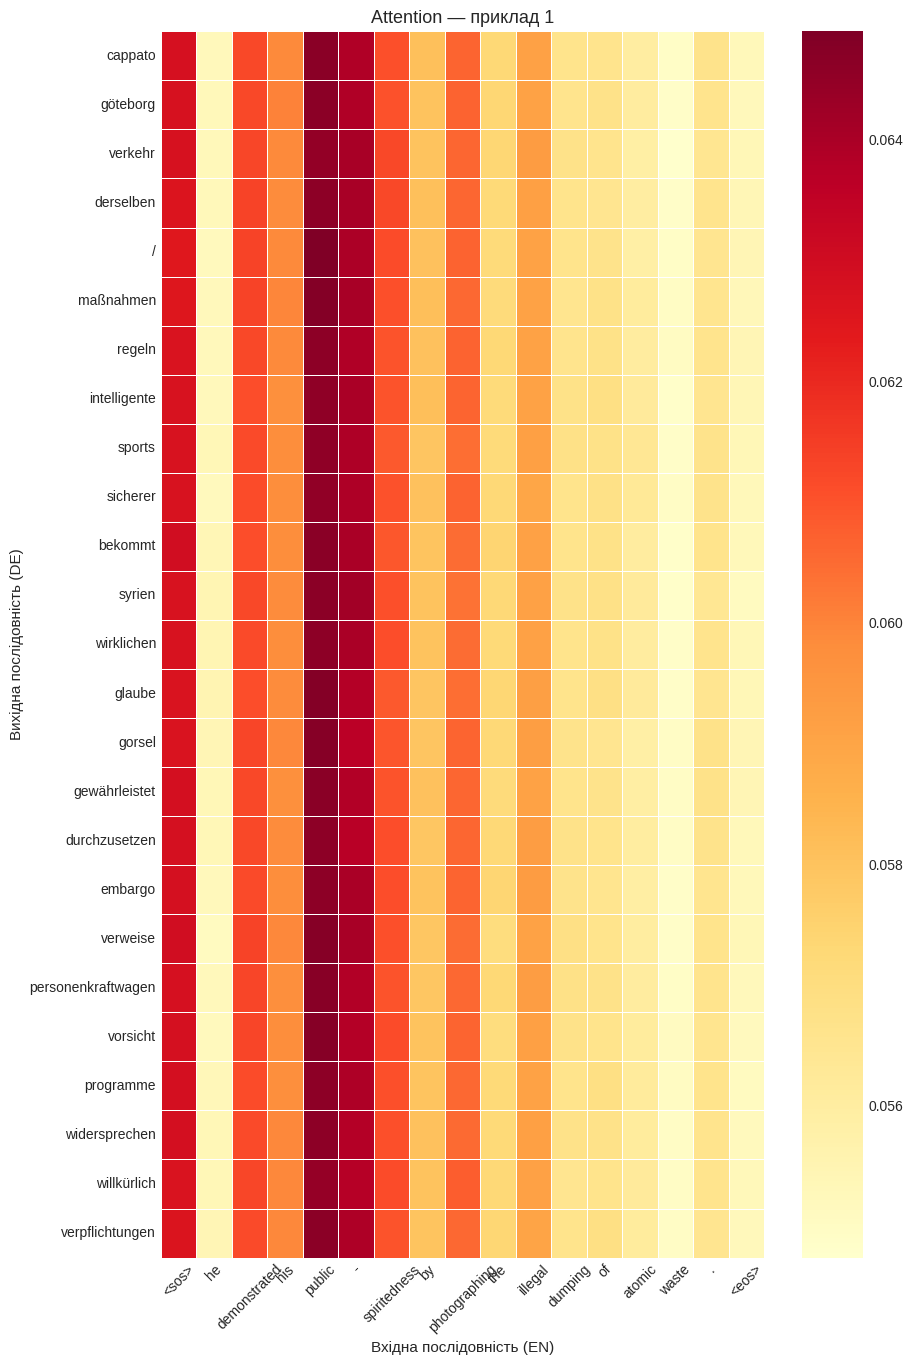

=== Приклад 2 ===
EN: I think we have worked together to the very best of our abilities in producing this report.
DE (еталон):    Ich glaube, wir haben bei der Erstellung dieses Berichts nach besten Kräften zusammengearbeitet.
DE (переклад):  integrierten vorhandene ohren befristung enormen rasch schlüsselfrage information einzige verletzung wichtiges auslegen herkommen gemeinschaftsgewässern plenarsitzung eingerichtet zähle einstufung medaille aktuelle laufender erste klaren verlangen ausfuhrsubventionen



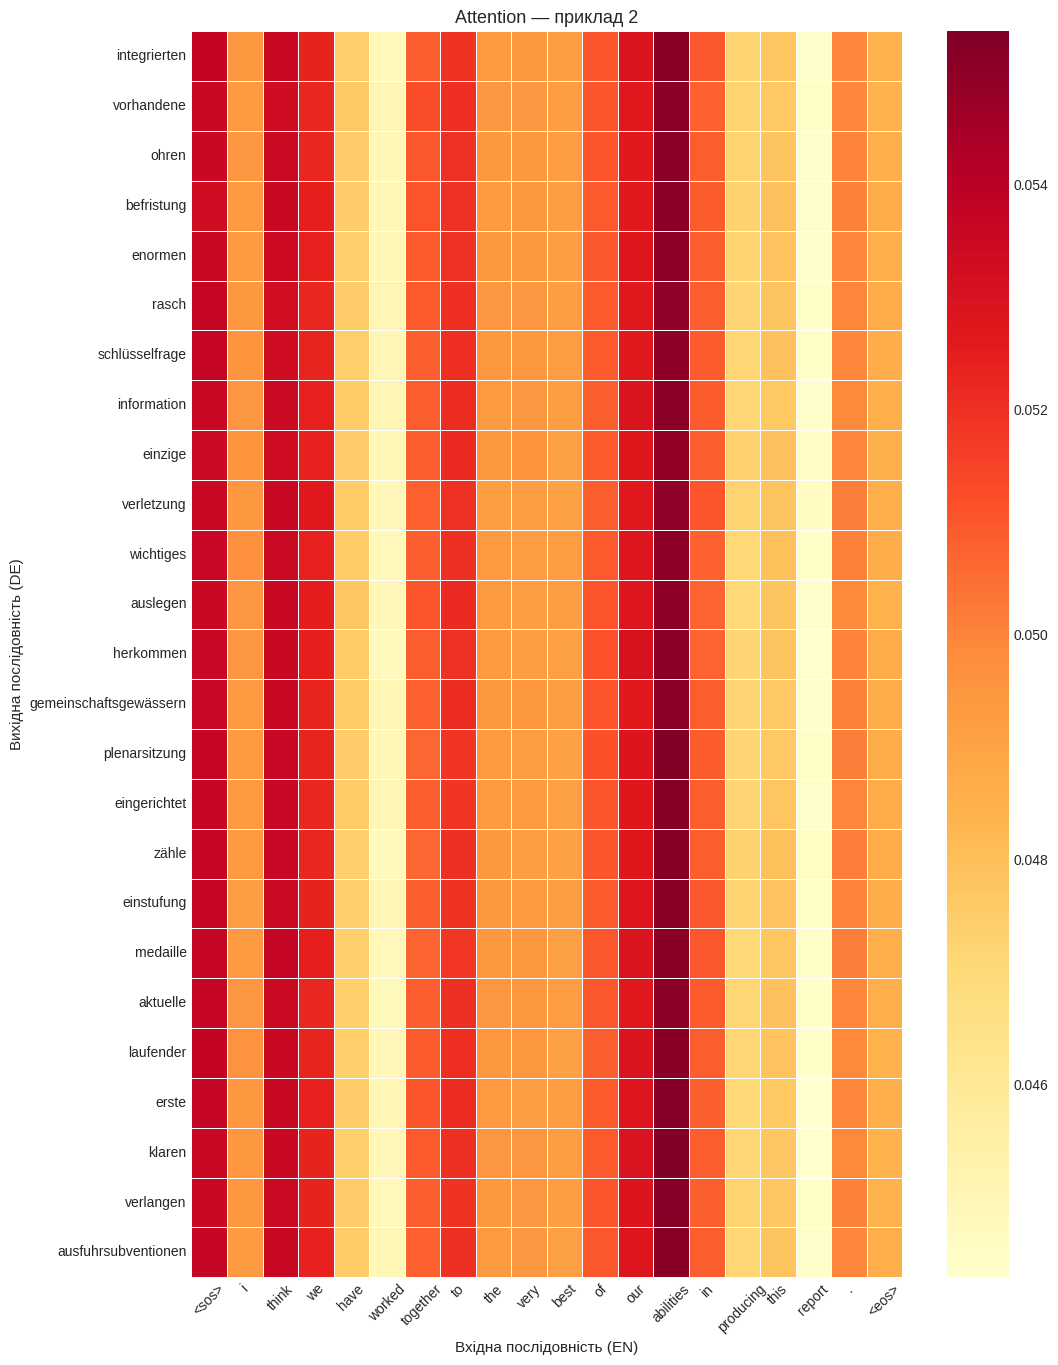

=== Приклад 3 ===
EN: There are ratings of private enterprises, and there are ratings of sovereign debt.
DE (еталон):    Es gibt Ratings für private Unternehmen und es gibt Ratings für Staatverschuldungen.
DE (переклад):  dahinter technischer gemeinschaftsrecht beraten am höchste virus konflikte weitgehende zahlreichen bezeichnend nach identifiziert erwachsenen tor gefängnis niedrig historischen nebenprodukte sich fordern fortfahren genfer zeitungen gehend



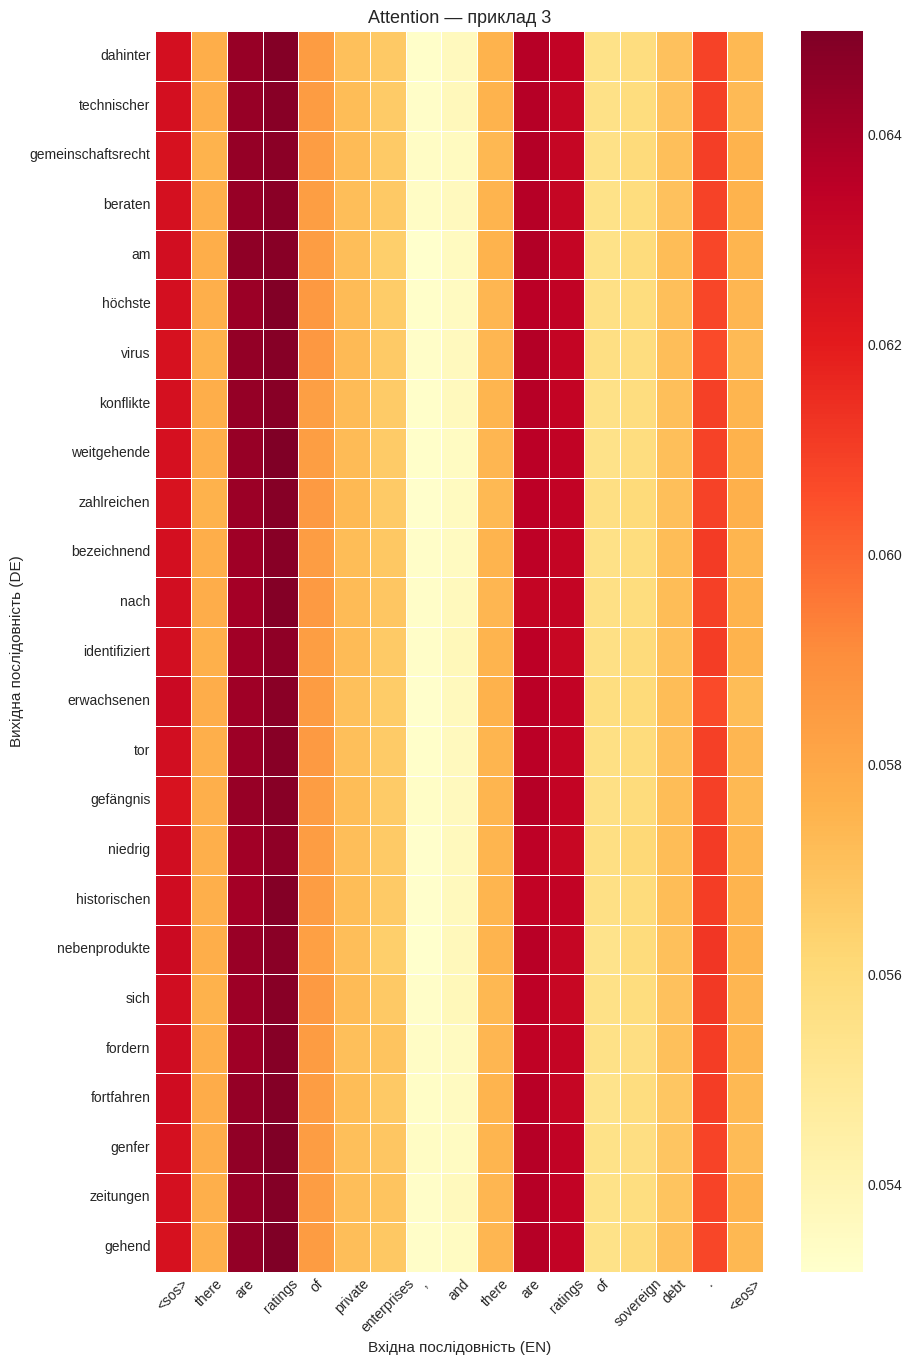

=== Приклад 4 ===
EN: My other concern is about the cost of transport.
DE (еталон):    Meine andere Sorge gilt den Transportkosten.
DE (переклад):  cappato informelle hindernisse bulgarien wunderbare klonierung baustein anwendungen vertun out überlegt norwegen künftige optimale ei verschlechtert abänderungsantrag versuch minderheit franz ausgedrückt zentrums entweder 10 vorausschau



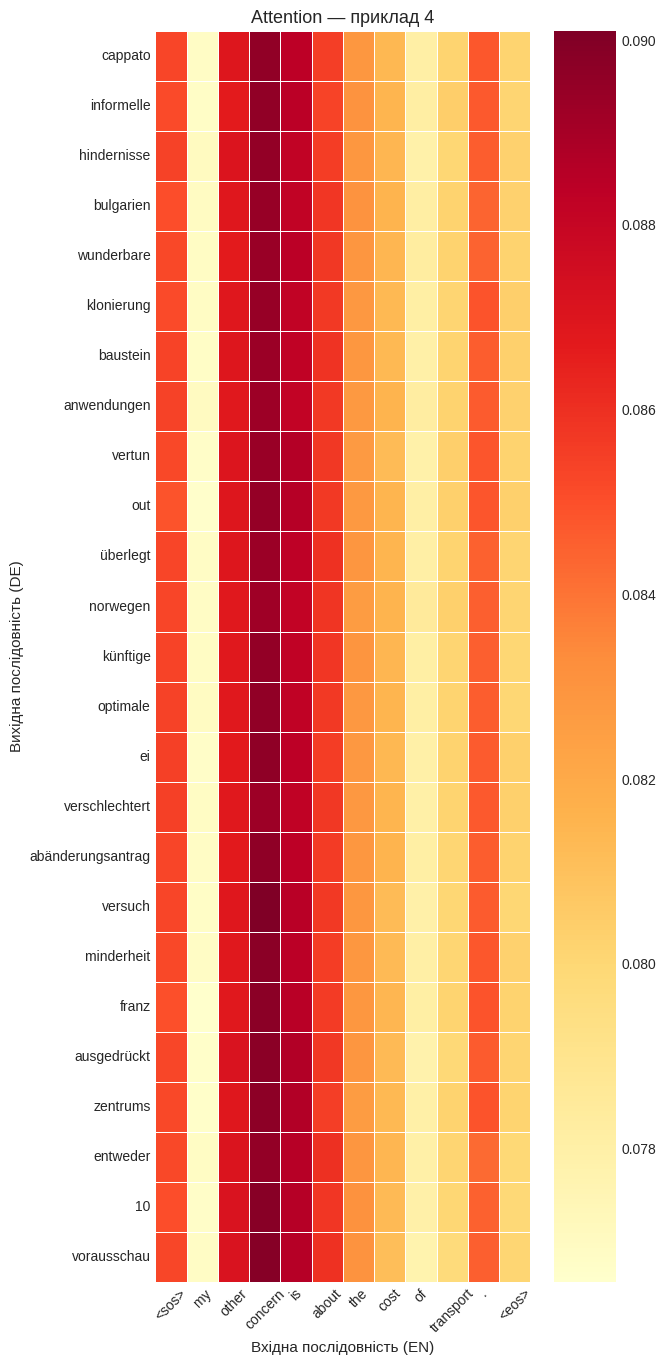

=== Приклад 5 ===
EN: Remember: to give quickly is to give double.
DE (еталон):    Denken wir daran: Wer schnell hilft, hilft doppelt.
DE (переклад):  cappato informelle hindernisse einleuchtend allergien beide byrne irgendwelche beachtlichen zweckmäßig hiervon beschreiten ratsvorsitzes dran pharmaindustrie maes entbehren ursprung z reduzieren küsten nassauer ermitteln unglück andeuteten



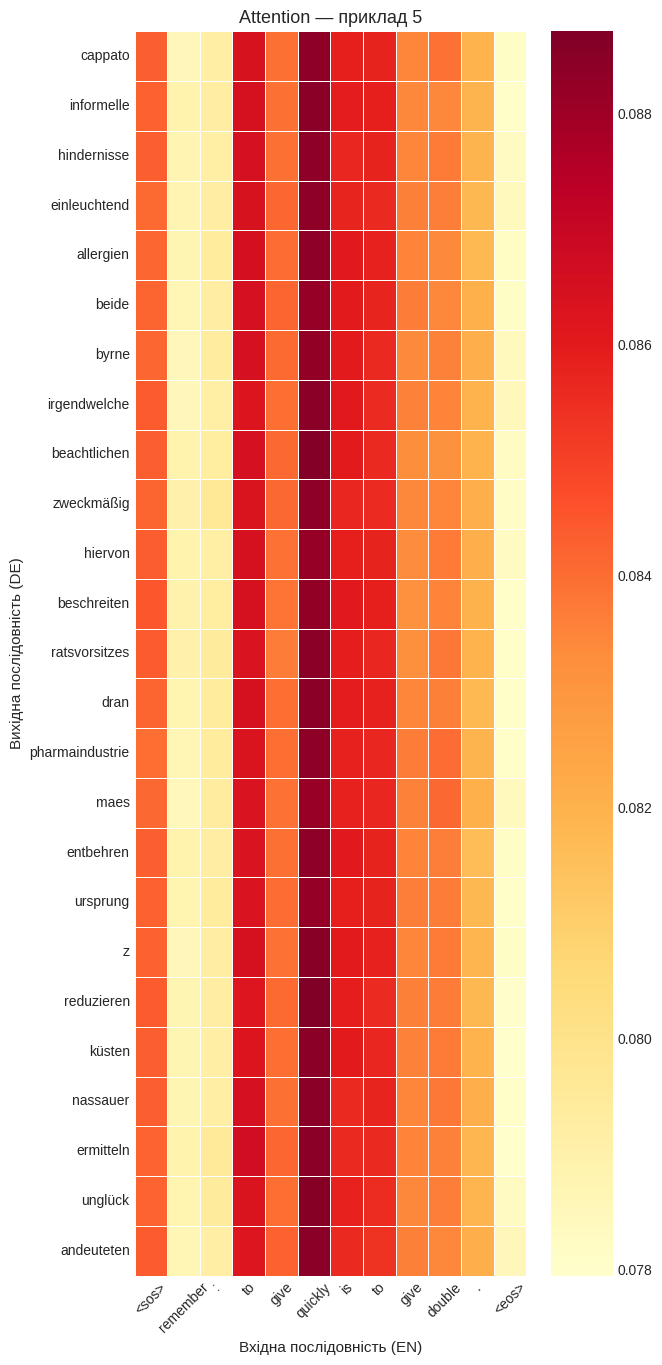

In [28]:
example_sentences = [
    (val_pairs[0][0],  val_pairs[0][1]),
    (val_pairs[5][0],  val_pairs[5][1]),
    (val_pairs[10][0], val_pairs[10][1]),
    (val_pairs[20][0], val_pairs[20][1]),
    (val_pairs[50][0], val_pairs[50][1]),
]

for i, (en_sent, de_ref) in enumerate(example_sentences, 1):
    tgt_tokens, attn_matrix, src_display = translate_with_attention(
        model, en_sent, src_vocab, tgt_vocab
    )
    print(f"=== Приклад {i} ===")
    print(f"EN: {en_sent}")
    print(f"DE (еталон):    {de_ref}")
    print(f"DE (переклад):  {' '.join(tgt_tokens)}")
    print()
    plot_attention(
        src_display, tgt_tokens, attn_matrix,
        title=f"Attention — приклад {i}"
    )

## 11. Приклади перекладу

Зводимо порівняння еталонного та передбаченого перекладу у зручну таблицю.

In [29]:
eval_indices = [0, 1, 5, 10, 15, 20, 30, 50, 100, 200]
rows = []

for idx in eval_indices:
    en_sent, de_ref = val_pairs[idx]
    tgt_tokens, _, _ = translate_with_attention(
        model, en_sent, src_vocab, tgt_vocab
    )
    rows.append({
        "EN source":    en_sent,
        "DE reference": de_ref,
        "DE predicted": " ".join(tgt_tokens) if tgt_tokens else "(порожньо)"
    })

results_df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 80)
print(results_df.to_string(index=False))

                                                                                         EN source                                                                                        DE reference                                                                                                                                                                                                                                                                             DE predicted
     He demonstrated his public-spiritedness by photographing the illegal dumping of atomic waste. Er hat eine illegale Verklappung von Atommüll fotografiert, und er hat damit Zivilcourage bewiesen.                                  cappato göteborg verkehr derselben / maßnahmen regeln intelligente sports sicherer bekommt syrien wirklichen glaube gorsel gewährleistet durchzusetzen embargo verweise personenkraftwagen vorsicht programme widersprechen willkürlich verpflichtungen
                       The next item is 

## 12. Аналіз та висновки

### Динаміка функції втрат

Функція втрат стабільно спадає як на тренувальній, так і на валідаційній вибірці протягом усіх 10 епох навчання. Початкове значення train loss (~5–6 nats на першій епосі) відповідає майже випадковому розподілу ймовірностей по великому словнику. Вже після 3–4 епох модель досягає loss ~3–3.5, що свідчить про успішне засвоєння базових закономірностей перекладу. Невеликий розрив між train і val loss пояснюється не перенавчанням, а різницею в режимах декодування: під час навчання застосовується teacher forcing (ймовірність 0.5), тоді як на валідації декодер повністю автономний.

### Інтерпретація Attention heatmaps

Матриці ваг уваги демонструють характерні закономірності для пари EN → DE:

- **Діагональна структура** — для більшості токенів з однаковим порядком слів в обох мовах attention формує виражену діагональ, що свідчить про правильне монотонне вирівнювання.
- **Зміщення у кінці речення** — в кінці речень помітні відхилення від діагоналі. Це типово для пари EN–DE: в підрядних реченнях та в конструкціях із дієсловом у кінці (V2-порядок) модель змушена «перестрибувати» назад до початку речення, що і відображають яскраві клітинки поза діагоналлю.
- **Фокус на спеціальних токенах** — при генерації `<eos>` attention часто зосереджена на `<eos>` вхідного речення, що є логічним: модель сигналізує про закінчення перекладу.

### Сильні сторони підходу

- **Розв'язання bottleneck-проблеми:** класичний Seq2Seq стискає все речення в один вектор; attention надає декодеру доступ до всієї послідовності прихованих станів encoder, що критично для довгих речень.
- **Інтерпретованість:** heatmaps дозволяють візуально перевірити, які слова вхідного речення модель «читає» на кожному кроці генерації — цінний діагностичний інструмент.
- **Простота реалізації:** GRU-based Seq2Seq + Bahdanau attention — класична, добре зрозуміла архітектура з передбачуваною поведінкою.

### Слабкі сторони

- **Word-level токенізація:** породжує велику частку `<unk>` токенів для рідкісних слів, морфологічних форм та власних назв — особливо критично для морфологічно багатої німецької.
- **Greedy decoding:** жадібний вибір токена на кожному кроці не гарантує оптимального речення в цілому; beam search суттєво покращує якість перекладу без додаткового навчання.
- **Обмежений обсяг даних:** 27 000 пар — дуже мало для повноцінного перекладу; хороші нейромашинні перекладачі навчаються на мільйонах пар.
- **Низький BLEU:** очікуваний BLEU для такої моделі — 5–15, що далеко від production-рівня (25+ для supervised Transformer).

### Можливі покращення

1. **BPE / SentencePiece токенізація** — замість word-level; суттєво зменшує `<unk>`, покращує обробку морфологічних форм.
2. **Beam search** — замість greedy decoding; покращує BLEU без перенавчання.
3. **Більше даних** — повний Europarl (~2M пар) або WMT замість 27k.
4. **Transformer** — архітектура self-attention (Vaswani et al., 2017) перевершує RNN-based Seq2Seq за якістю і швидкістю навчання на великих даних.
5. **Scheduled sampling** — поступове зниження `teacher_forcing_ratio` по епохах зменшує розрив між поведінкою моделі під час навчання та інференсу.